# Intro to spike data and Whats the upper limit on performance?

## Intro
We are now providing the raw data from which the data you have been competing on was derived. The raw data consists of every trial an image was shown to a neuron and exactly when the neuron spiked relative to the onset of that stimulus. One advantage to having the original trials is that you can get an estimate of the variability from trial-to-trial which in turn can give you a sense of how much noise vs signal there is in the data, which in turn can help you estimate how well you can perform on predicting a given neurons responses. There might be other advantages to having this finer grained dataset but its up to you to find them at the very least you may find the data interesting! So now I'll give you a tour of this new dataset then see if we can estimate the ceiling on performance. 

### Loading spike data
The spike data is stored in '.nc' files which are used by the xarray package for loading and saving data. xarray is a great package for exploring data when it is multidimensional e.g. it was largely developed for climate science where data is collected over latitude, longtidude, altitude and many measurements are made at each of those positions e.g. temperature, humidity, etc. This format works well for neural data where the dimensions are time, trials, neurons, stimuli, lets take a look:


In [1]:
import xarray as xr #importing xarray
import pandas as pd # importing pandas to make comparison to processed data
import numpy as np
import os 
import matplotlib.pyplot as plt 
%matplotlib inline

#load the processed data you originally got
df = pd.read_csv('../input/train.csv')
df.index = df.Id#turn the first col to index
df = df.iloc[:,1:]#get rid of first col that is now index
stim = np.load('../input/stim.npy')

da = xr.open_dataset('../input/spike_data.nc')['resp']#read in the spike data (1gb)
print(da)

<xarray.DataArray 'resp' (stim: 551, trial: 17, unit: 18, t: 800)>
[134884800 values with dtype=float64]
Coordinates:
  * t        (t) float64 -0.15 -0.149 -0.148 -0.147 ... 0.646 0.647 0.648 0.649
  * stim     (stim) int32 50 51 52 53 54 55 56 ... 594 595 596 597 598 599 600
    stim_t   (unit, stim, trial) float64 ...
    iso      (unit, trial, stim) float64 ...
  * unit     (unit) object '10_1_2018_0_0' '10_1_2018_0_1' ... '9_28_2018_0_1'
  * trial    (trial) int32 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16


So this is a DataArray of of all the spike data on the top line it list of the data dimensions and the number of items along that dimension. So there are 551 stimuli, up to 17 trials, 18 units, 800 discrete time points (each is a milisecond). In the coordinate listed below the top line the dimensions with  a * are primary dimensions (meaning you use these to index) and without a * are auxillary simply giving a description of the data (iso is the quality of isolation from 0 to 4, and stim_t is the time of the stimuli with respect to the beginning of the experiment).  Now lets look at some spike data:

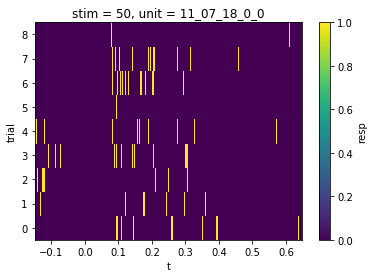

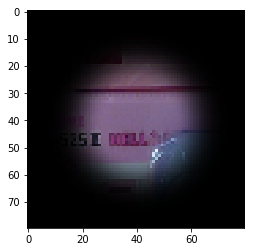

In [2]:
da.isel(unit=4).sel(stim=50).dropna('trial').plot();#the 4th unit, the 50th stimulis
#isel selects based on the order of the data (0-n) and sel based on the labels of the data.
#nans fill up where data was not collected so for this cell 5 trials were collected so the other 
#trials are filled with nans so I drop them along the trial axis.
plt.figure()
plt.imshow(stim[0])

So this is typical neural data. The time axis is second since the stimulis presentaiton where negative numbers are before and positive after. Each yellow line is the time when a spike arrived blue is when no spike arrived. You can see that the number of spikes increases rapidly after about 0.05 seconds post stimulus, this is the result of a typical neural delay.  One thing to notice is that the number of spikes is clearly different from trial to trial on some only one spike and on others a dozen. Thus any estimate of the expected number of spikes is going to be a noisy estimate. Since you are fitting a noisy estimate it is unlikely for you to be able to capture all the variance but how bad is it? Lets do a simulation!

It is typicaly to model the number of spikes a neuron emits given a stimulus as Poisson distributed:
$$Y_i \sim P(\lambda_i)$$
Where $Y_i$ is the number of spikes in response to the $ith$ of $m$ stimuli and it is Poisson distributed with mean $\lambda_i$. 
For a Poisson random variable the mean is equal to the variance: $$E[P(\lambda_i)] = Var[P(\lambda_i)] = \lambda_i$$ which is alot of variability!
A typical experiment involves showing each of the $m$ stimuli $n$ times then averaging the response to reduce this variability and in addition it is heteroscedastic (different stimuli give responses with different variability):
$$\bar{Y}_i = \frac{1}{n} \sum_j^n Y_{i,j} \sim \frac{1}{n} P(n \lambda_i)$$
By performing a square root transformation and invoking the CLT the problem becomes easier. First lets see what happens when we take the square root of our responses:
$$E[\sqrt{P(\lambda)}] \approx \sqrt{\lambda}$$ this is a reasonable approximation
$$Var[\sqrt{P(\lambda)}] \approx \frac{1}{4}$$ the variance becomes a known constant

so $$\bar{Y}_i = \frac{1}{n} \sum_j^n \sqrt{Y_{i,j}} \sim \frac{1}{n} \sum_j^n{\sqrt{P(\lambda_i)}}$$

$$E[\bar{Y}_i] = \frac{1}{n} \sum_j^n E[\sqrt{Y_{i,j}}] \approx \sqrt{\lambda_i}   $$
$$Var[\bar{Y}_i] = \frac{1}{n^2} \sum_j^n Var[\sqrt{Y_{i,j}}] \approx \frac{1}{4n}   $$

Finally invoking the CLT we approximate the average with normal random variables and have:
$$\bar{Y}_i \sim N(\sqrt{\mu_i}, \frac{1}{4n})$$
Great so we are in very friendly terrain a normal random variably with known variance! This is after a fair amount of approximations and assumptions the worst of which I would say is assuming the neurons are poisson distributed as often you will find their variance is higher than their mean. But as a first pass it should give us a sense of which neurons have good SNR and which don't.

So our simulation plan will be to take the average of the square root of responses then simulate the response to each stimulus as $N(\bar{Y_i}, \frac{1}{4n})$ and then with the 'perfect model' $\bar{Y_i}$ (the true means of our simulated responses) see what a typical r value is to it.

In [3]:
    da_p = da.sel(t=slice(.05, .35))#grab only the times from 50ms to 350 ms post stimulus
    da.sum('t')
    m = np.sqrt(da.sum('t')).mean('trial',skipna=True)
    v = np.sqrt(da.sum('t')).var('trial', skipna=True).mean('stim')
    print(v.values)
    v[v<0.25] = 0.25
    s2 = v/n
    xr_l.append(m)

[ 6.60290507  0.12187969  4.19620791  0.13717637  1.28395279  6.64019306
  3.57289527  0.24308728  0.23883128 21.82763398  0.36782723  5.10571622
  4.75788293  1.90427937  2.67755426  0.89659936  3.85382978  0.04059307]


NameError: name 'n' is not defined

### Stimuli
Now lets look at the stimuli:

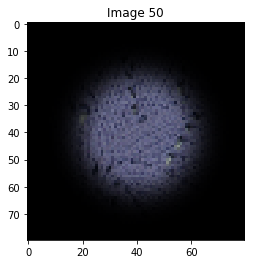

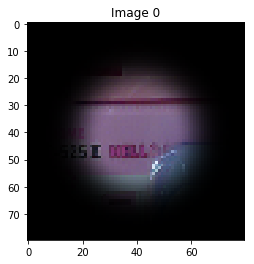

In [4]:
a_train_ind = 50
plt.imshow(stim[a_train_ind]);
plt.title('Image ' + str(a_train_ind));
plt.figure();
a_test_ind = 0
plt.imshow(stim[a_test_ind]);
plt.title('Image ' + str(a_test_ind));

The image on top has Id 50, which is from the training data, and so we know the spike number. So for example the single unit recorded on 10/1/2018 (2nd column in table above) had on average  $1.5^2$ spikes in response to this image. The ability of your algorithm to predict the responses to images 0-49 will determine your performance in the competition.

### Creating a simple model
To get you started and help you understand how to submit your results I will make a simple model below and submit its results. My hypothesis will be that all neurons are generally responding to the average color in the image. So I will take each image calculate the total amount of red, green, and blue then find the coefficients that best predict the respons of the neuron on the basis these three features. Quantitatively my hypothesis will be that the number of spikes is a linear combination of the amount of red green and blue in an image.


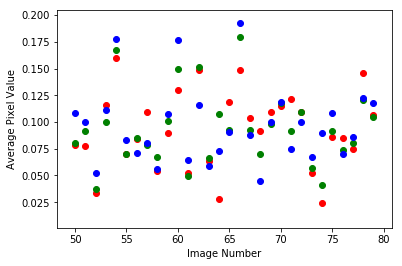

In [5]:
rgb = np.mean(stim, (1,2))#average RGB across rows and columns of each image
for i, c in enumerate(rgb.T):
    plt.scatter(range(len(c))[50:80], c[50:80], color=['r','g','b'][i], alpha=1);
plt.ylabel('Average Pixel Value');plt.xlabel('Image Number');

Just looking at the test a sample of the average RGB values for the images we can see some  have similar amounts of red green and blue (all points near each other) on different. Now lets take the RGB averagevalues from the training images and regress them on spike number.

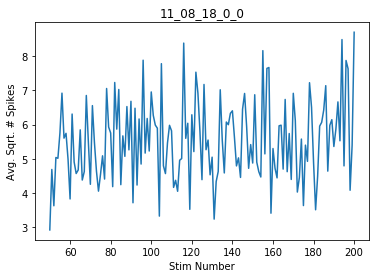

In [6]:
rec = df.iloc[:, 6].dropna()#use the command dropna as this cell only was shown 0-200 images
rec.plot();
plt.xlabel('Stim Number');plt.ylabel('Avg. Sqrt. # Spikes');
plt.title(rec.name);

The cell clearly responded with more spikes to some images than it did to others, lets see if we can get an intuition for what evoked a large number of spikes by looking at the images which evoked the greatest average number of spikes:
Lets look at the images the cell preferred the most:

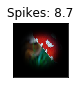

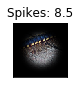

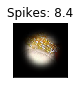

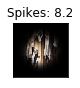

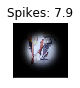

In [7]:
top_n = 5
best_resp_inds = rec.argsort()[::-1].values
for ind in best_resp_inds[:top_n]:
    plt.figure(figsize=(1,1))
    plt.imshow(stim[50:][ind]/np.max(stim[50:][ind]));
    plt.xticks([]);plt.yticks([])
    plt.title('Spikes: ' + str(np.round(rec.iloc[ind],1)))


What would you guess the cell prefers? How would you perform a computation on these images which approximated that intuition? Lets see how well the rgb model does.


In [8]:
rec = df.iloc[:, 6].dropna()#select the 6th column recording
x = rgb[50:][:len(rec)]#select the rgb averages for the training images 50:
y = rec.values#get the numerical values from the recording
A = np.hstack([x, np.ones((len(y), 1))])#create a matrix of predictors RGB and a constant for the intercept
coefs = np.linalg.lstsq(A, y, rcond=None)[0];#now regress our predictors on the responses and get the coefficients of the model A * coefs=y
fit_y = np.dot(A, coefs)#get the predicted values of this model.

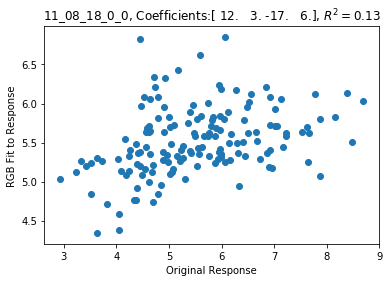

In [9]:
plt.scatter(y, fit_y);#scatter the true responses against the fit of the linear model
r = np.corrcoef(fit_y, y)[0,1]**2#get the correlation squared (fraction of variance explained)
plt.title(rec.name + ', Coefficients:' + str(np.round(coefs)) + 
          r', $R^2=$' + str(round(r,2)));
plt.xlabel('Original Response');
plt.ylabel('RGB Fit to Response');

So we account for a little over 10% of the variance using a very simple feature for the population recorded from on November 8th. The coefficient on red was 12 so when there was alot of red the cell tended respond the most, coefficient on green was 3 so green was associated with higher responses as well, whereas when blue was present the cell tended to fire very little on average. Can you think of other features you can extract from the image that might better predict responses?

### Example submission

Now lets organize all of our responses for a submission. The submission will be a matrix which has 50 rows for each of the held out respones and a column for each individual recording. 


In [10]:
test_preds = [] # create list to contain predictions
trainr2 = [] # list for fit to training data
A = np.hstack([rgb, np.ones((rgb.shape[0], 1))]) #linear predictors rgb, and constant(intercept)
for i in range(df.shape[1]):#for each recording
    rec = df.iloc[:, i].dropna()#get recording drop nan responses for images not shown
    y = rec.values # load responses into numpy array
    A_train = A[50:][:len(rec)]#get features of images we have responses for
    A_test = A[:50]#get features for test images you are making prediction on
    #train model i.e. regress rgb values onto responses
    coefs = np.linalg.lstsq(A_train, y, rcond=None)[0];
    fit_train_y = np.dot(A_train, coefs)#get the prediction for known responses
    trainr2.append(np.corrcoef(y, fit_train_y)[0,1])
    fit_test_y = np.dot(A_test, coefs)#use coefficients found for training data to make prediction on test data
    test_preds.append(fit_test_y)# append these predictions

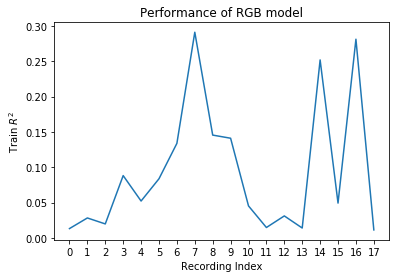

In [11]:
test_preds = np.array(test_preds)#convert predictions to array
trainr2= np.array(trainr2)
plt.plot(trainr2**2);plt.xlabel('Recording Index');plt.ylabel(r'Train $R^2$');
plt.xticks(range(len(trainr2)));plt.title('Performance of RGB model');

### Submitting results
Now the final step is putting your results into a submittable format

In [12]:
sdf = pd.DataFrame(test_preds.T)
sdf.columns = df.columns#replace the columns with the correct cell ids from training data
sdf.index.name = 'Id'
sdf.to_csv('sub.csv')#save to csv
sdf.head()#show top couple rows of submission

,10_1_2018_0_0,10_1_2018_0_1,11_06_18_0_0,11_06_18_0_1,11_07_18_0_0,11_07_18_1_0,11_08_18_0_0,11_08_18_0_1,11_09_18_0_1,9_17_2018_0_0,9_17_2018_0_1,9_20_2018_0_0,9_21_2018_0_0,9_21_2018_0_1,9_26_2018_0_0,9_26_2018_0_1,9_28_2018_0_0,9_28_2018_0_1
Id,,,,,,,,,,,,,,,,,,
0,7.872480,0.595127,6.163015,0.497040,3.137307,7.409312,5.249370,0.816530,1.407607,6.768578,0.403631,4.111969,3.064643,1.752595,2.285746,1.178161,6.018130,0.191368
1,7.813741,0.491782,6.040484,0.352563,3.585404,8.184495,6.231991,0.301066,1.006550,6.609808,0.316571,3.909398,2.952563,1.860525,1.782857,1.260709,7.604532,0.085246
2,7.941762,0.594214,6.203440,0.499033,3.132742,7.377352,5.445710,0.915789,1.429496,6.879706,0.415421,4.084730,3.144312,1.766072,2.509841,1.108468,5.990778,0.184685
3,7.864636,0.789445,6.107043,0.445449,2.951779,7.201266,4.821422,0.939443,1.343724,6.680236,0.363774,3.994020,3.072019,1.837692,2.280930,1.249072,5.514029,0.233642
4,7.871483,0.782379,6.146974,0.497627,2.856610,7.018910,4.581186,1.050221,1.470372,6.724897,0.395086,4.081200,3.089825,1.787110,2.391196,1.223071,5.149445,0.257844


And thats it, you are ready to submit. If you run this notebook on your own computer then it will save sub.csv to the current directory and you just need to upload that to submissions in Kaggle. If you fork this notebook and run it then it will save to 'Output' so if you open the notebook under the 'Kernels' then 'Your Work' tab then 'Output' tab you will see a button to submit your results, and thats it! 


In [13]:
da.isel(unit=0);#the 4th unit, the 50th stimulis
#isel selects based on the order of the data (0-n) and sel based on the labels of the data.
#nans fill up where data was not collected so for this cell 5 trials were collected so the other 
#trials are filled with nans so I drop them along the trial axis.
da_p = da.sel(t=slice(.05, .35))#grab only the times from 50ms to 350 ms post stimulus
da.sum('t')
m = (da.sum('t')).mean('trial',skipna=True)
m = m.values.T


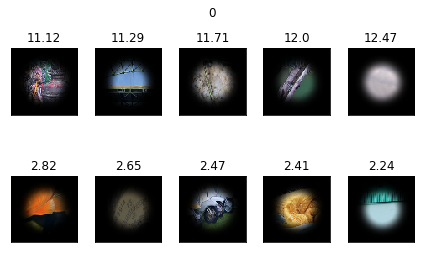

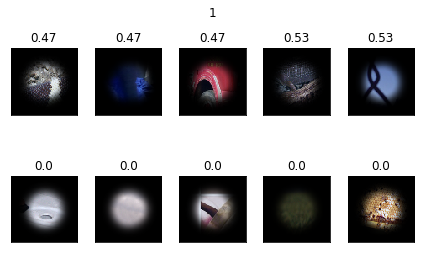

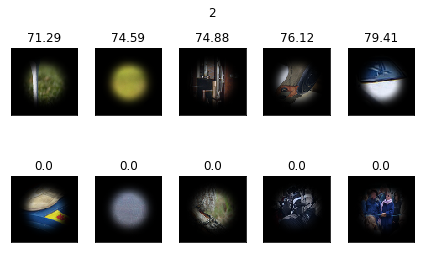

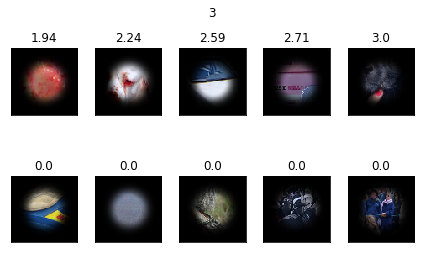

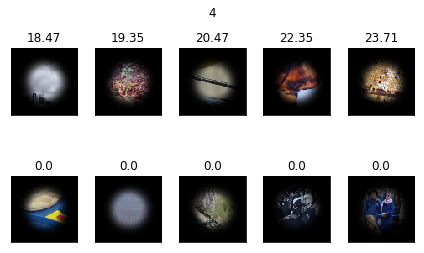

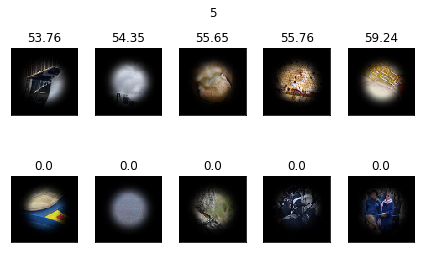

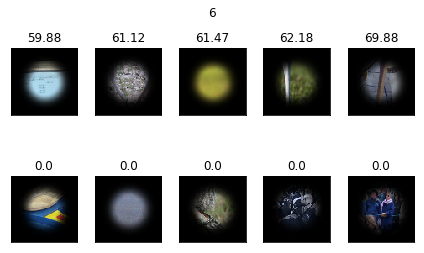

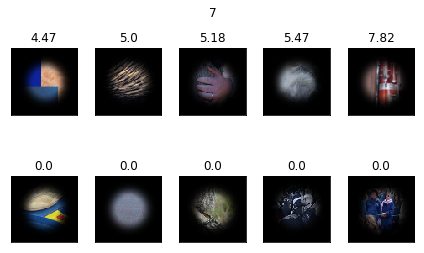

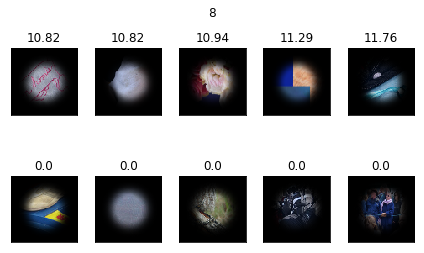

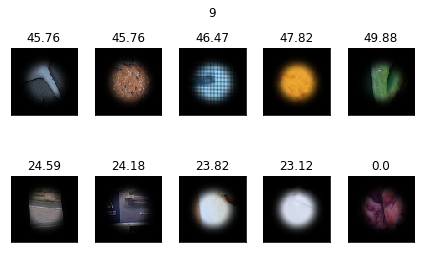

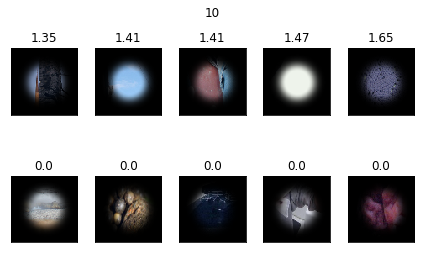

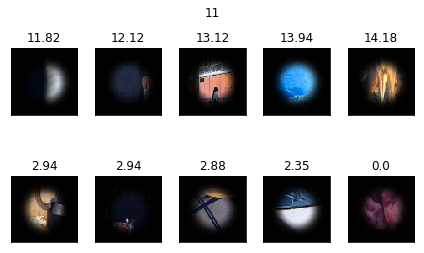

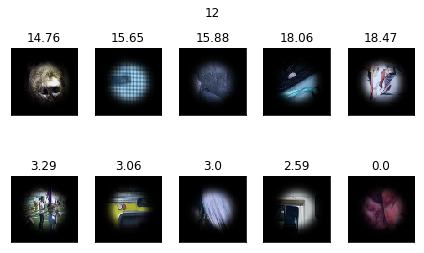

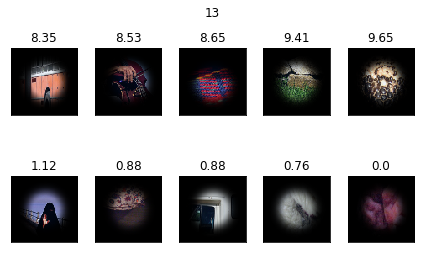

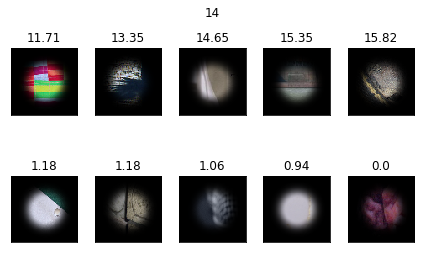

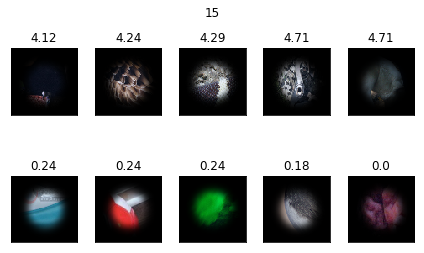

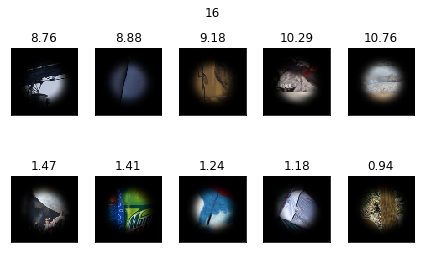

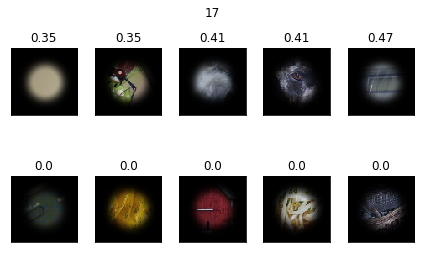

In [14]:

top_bot = [-5,-4,-3,-2,-1, 4, 3,2, 1, 0]
for unit_n, unit in enumerate(m):
    plt.figure()
    
    inds = np.argsort(unit)
    for i, ind in enumerate(top_bot):
        plt.subplot(2,len(top_bot)/2, i+1)
        im = stim[inds[ind]].squeeze()
        plt.imshow(im);plt.xticks([]);plt.yticks([])
        plt.title(np.round(unit[inds[ind]],2))
    plt.tight_layout()
    plt.suptitle(unit_n)
    